importing Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from sklearn.model_selection import train_test_split,cross_val_score , KFold
from sklearn.linear_model import LinearRegression, Ridge,Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_log_error, mean_absolute_error , r2_score
from sklearn. pipeline import make_pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
pd.set_option("display.width",140); pd.set_option("display.max_columns", 40)
RANDOM_STATE =42

Load the dataset and perform EDA

In [40]:
df = pd.read_csv("kc_house_data.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
(df.isnull().sum()/len(df))*100
df.duplicated().sum()
df.describe()
df.describe(include="all")
df.select_dtypes(include=np.number).columns
df.select_dtypes(include="object").columns


<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          4999 non-null   int64  
 1   bedrooms    4999 non-null   int64  
 2   bathrooms   4999 non-null   float64
 3   Area        4999 non-null   int64  
 4   floors      4999 non-null   float64
 5   condition   4999 non-null   int64  
 6   year built  4999 non-null   int64  
 7   location    4999 non-null   str    
 8   Garage      2000 non-null   str    
 9   price       4999 non-null   str    
dtypes: float64(2), int64(5), str(3)
memory usage: 390.7 KB


Index(['location', 'Garage', 'price'], dtype='str')

House Price Distribution

In [41]:
df.columns.tolist()

['id',
 'bedrooms',
 'bathrooms',
 'Area',
 'floors',
 'condition',
 'year built',
 'location',
 'Garage',
 'price']

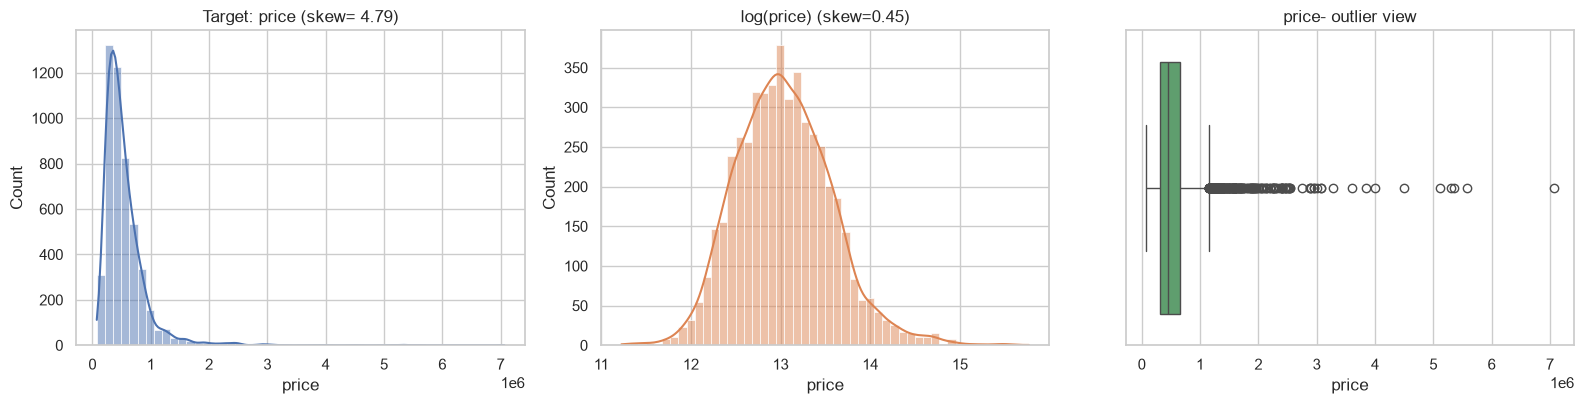

price: mean: 539,366 | median: 449,000.00 |  std387,137


In [42]:
df["price"] = pd.to_numeric(df["price"].astype(str).str.replace(",", ""), errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Target: price (skew= {df['price'].skew():.2f})")
sns.histplot(np.log(df['price']), bins=50, kde=True, ax=axes[1], color= "#DD8452") 
axes[1].set_title(f"log(price) (skew={np.log(df['price']).skew():.2f})")
sns.boxplot(x=df["price"], ax=axes[2], color="#55A868")
axes[2].set_title("price- outlier view")
plt.tight_layout(); plt.show()
print("price: mean: {:,.0f} | median: {:,.2f} |  std{:,.0f}".format(df['price'].mean(), df["price"].median(), df["price"].std()))

Observation

The python code cleans and converts the price column into numeric data,while the log transformation effectively reduces the severe right skew.

Feature Selection Reasoning Before Modeling

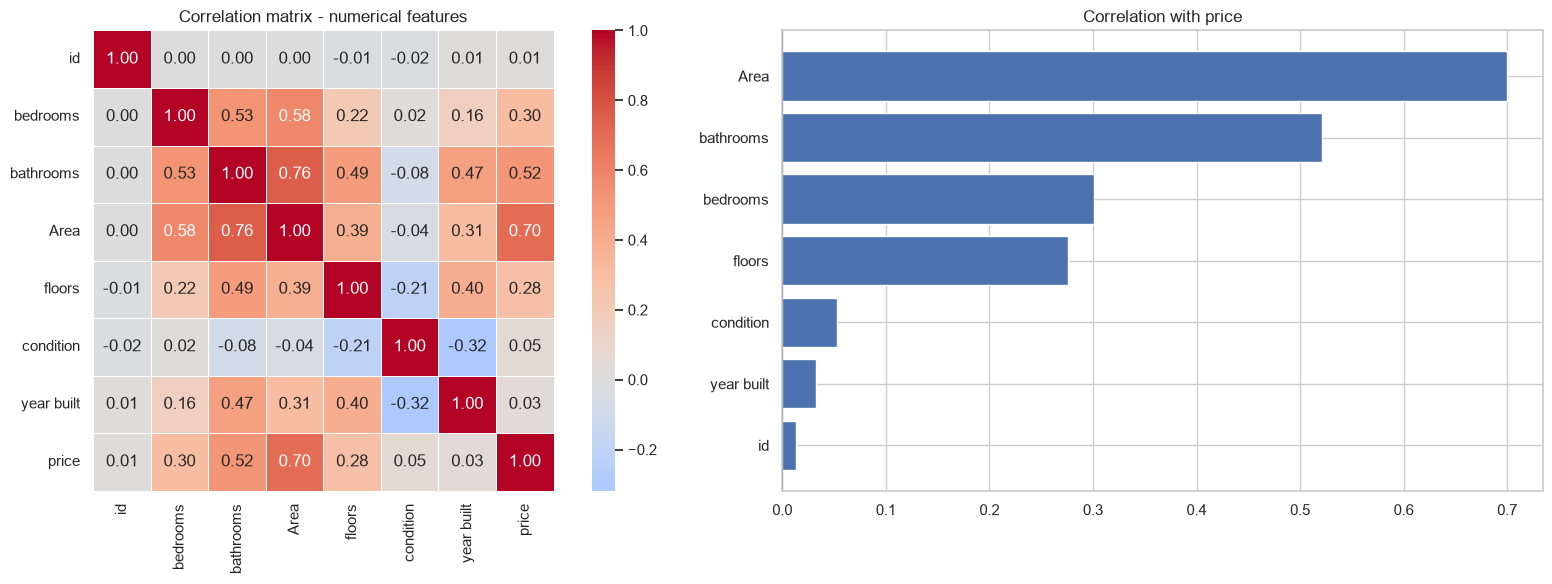

Area          0.700
bathrooms     0.521
bedrooms      0.301
floors        0.276
condition     0.053
year built    0.032
id            0.013
Name: price, dtype: float64


In [43]:
df["price"] = pd.to_numeric(
    df["price"].astype(str).str.replace(",",""), errors="coerce"
)
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

fig, axes = plt.subplots(1,2, figsize=(17,6))
sns.heatmap(corr , annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0],square=True,linewidth=0.4,)
axes[0].set_title("Correlation matrix - numerical features")
price_corr = corr["price"].drop("price").sort_values()
axes[1].barh(price_corr.index, price_corr.values, color=["#C44E52" if v < 0 else "#4C72B0" for v in price_corr.values],)

axes[1].set_title("Correlation with price"); 
axes[1].axvline(0, color="k", lw=0.8)
plt.tight_layout();plt.show()
print(corr["price"].drop("price").sort_values(ascending=False).round(3))

Observation

the  correlation heatmap and bar chart show  the liner relationships between numerical features and the target variable price.

area exhibits the strongest positive correlation with price at0.70, followed bathrooms(0.52)and bedrooms (0.30).


Missing values and One-Hot  Encoding

In [44]:
data = df.copy()
# --- missing values, with a stated reason for each choice

data.columns = data.columns.str.strip().str.lower()
if"beadrooms" in data.columns:data["bedrooms"] = data["bedrooms"].fillna(data["bedrooms"].median())
if"floors"in data.columns:data["floors"].fillna(data["floors"].mode()[0])
cat_cols = data.select_dtypes(include=["object","category"]).columns.tolist()
print("Categorial colomns:", cat_cols)
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
data = data.astype(float)
print(f"\ncolumns:{df.shape[1]} - {data.shape[1]} after encoding")

   

Categorial colomns: ['location', 'garage']

columns:10 - 11 after encoding


Train/test split and model training

In [45]:
df = pd.read_csv("kc_house_data.csv")
df.columns = df.columns.str.strip().str.lower()
df["price"] = pd.to_numeric(
    df["price"].astype(str).str.replace(",", ""), errors="coerce"
)
data = df.copy()
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_cols:
    data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
    
data = data.dropna()    
X = data.drop(columns="price")
y = data["price"]
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.20, random_state=RANDOM_STATE)
print(f"train: {X_train.shape} | test:{X_test.shape}")
lin  = LinearRegression()
lin.fit(X_train, y_train )

lin_log = LinearRegression()
lin_log.fit(X_train, np.log1p(y_train))

print("/nModels fitted: LinearRegression on price, and o log(price)")
print("intercept:", round(lin.intercept_, 2))



train: (3999, 10) | test:(1000, 10)
/nModels fitted: LinearRegression on price, and o log(price)
intercept: 529158.88


Evalution-MSE,RMSE,R^2

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate (name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true -y_pred) / y_true)) * 100
    return{
        "Model":name,
        "MSE": rmse,
        "MAE":mae,
        "R2": r2,
        "MAPE%": mape,
 }

y_pred = lin.predict(X_test)
y_pred_log = np.exp(lin_log.predict(X_test))
rows = [
    evaluate("Linear Regression (price)", y_test, y_pred), 
    evaluate("Linear Regression (log price)", y_test, y_pred_log),
]
res = pd.DataFrame(rows).set_index("Model")
print(res.round(3).to_string(float_format=lambda v: f"{v:,.3f}"))

cv = cross_val_score(
    LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state= RANDOM_STATE),scoring="r2")
print(f"\n5-flod CV R2: {cv.mean():.4f}(+/- {cv.std():.4f})")
print(f"Train R2: {lin.score(X_train, y_train):.4f} | Test R2: {lin.score(X_test, y_test):.4f}")

                                      MSE         MAE     R2  MAPE%
Model                                                              
Linear Regression (price)     376,150.340 241,591.859 -0.001 56.339
Linear Regression (log price) 386,639.308 233,841.887 -0.057 46.753

5-flod CV R2: -0.0013(+/- 0.0012)
Train R2: 0.0002 | Test R2: -0.0008


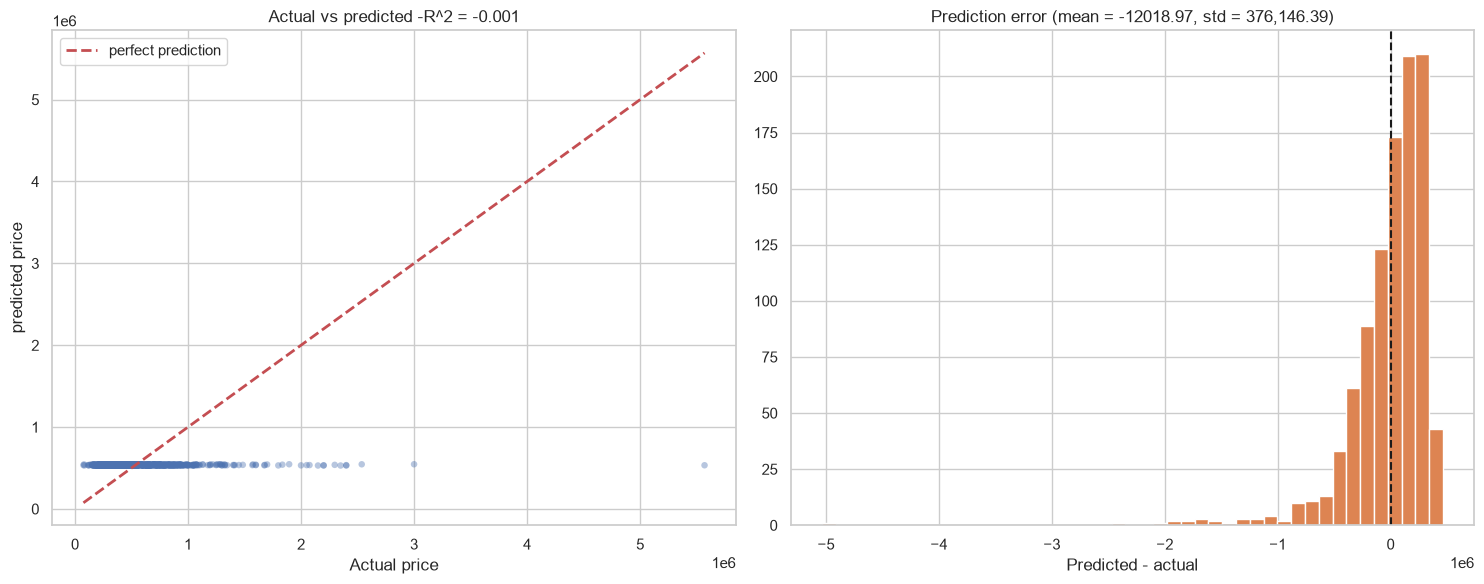

predictions within 10% of actual: 12.2%
predictions within 20% of actual: 26.9%


In [47]:
fig, axes = plt.subplots(1,2, figsize=(15, 6))
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(),y_pred.max())]
axes[0].scatter(y_test, y_pred, alpha=0.4, s=22, color="#4C72B0", edgecolor="none")
axes[0].plot(lims, lims, "r--", lw=2, label="perfect prediction")
axes[0].set_xlabel("Actual price"); 
axes[0].set_ylabel("predicted price")
axes[0].set_title(f"Actual vs predicted -R^2 = {r2_score(y_test, y_pred):.3f}")
axes[0].legend()
err = y_pred - y_test
axes[1].hist(err, bins=45, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="k" ,ls="--")
axes[1].set_title(f"Prediction error (mean = {err.mean():.2f}, std = {err.std():,.2f})")
axes[1].set_xlabel("Predicted - actual")
plt.tight_layout(); plt.show()
within = lambda p: np.mean(np.abs(err) / y_test < p)
print(f"predictions within 10% of actual: {within(.10):.1%}")
print(f"predictions within 20% of actual: {within(.20):.1%}")


observation

The actual versus predicted plot and the negative R2 score of -0.001 indicate that the model performs worse than a simple baselie.

Residual analysis

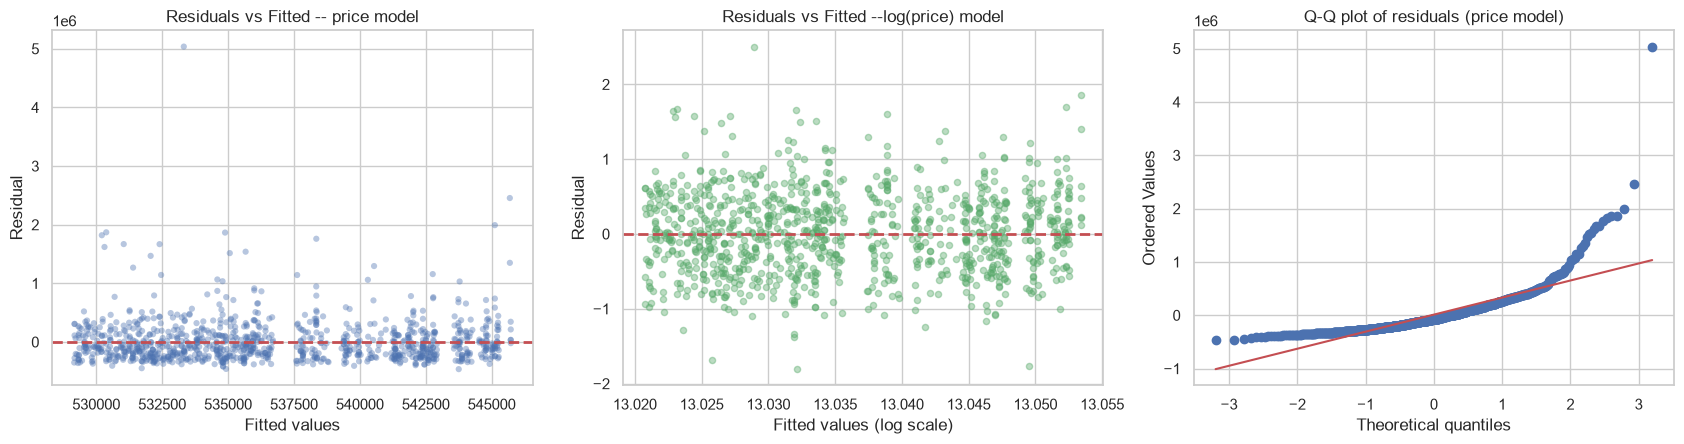

Residual mean:12,019.0 (should be  ~0)
Residual std : 376,146.4
Skew:4.148 | Kurtosis: 37.078
corr(|residual|, fitted):-0.020(near 0 = homescedastic)


In [48]:
residuals = y_test - y_pred
residuals_log = np.log(y_test) - lin_log.predict(X_test)
fig, axes = plt.subplots(1, 3,figsize=(17, 4.6))
axes[0].scatter(y_pred, residuals, alpha=0.4, s=20, color="#4C72B0", edgecolor="none")
axes[0].axhline(0, color="r", ls="--", lw=2)
axes[0].set_xlabel("Fitted values"); 
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted -- price model")
axes[1].scatter(lin_log.predict(X_test), residuals_log, alpha=0.4, s=20, color="#55a868",)
axes[1].axhline(0, color="r", ls="--", lw=2)
axes[1].set_xlabel("Fitted values (log scale)"); 
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted --log(price) model")

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals (price model)")
plt.tight_layout(); plt.show()
print("Residual mean:{:,.1f} (should be  ~0)".format(residuals.mean()))
print("Residual std : {:,.1f}".format(residuals.std()))
print("Skew:{:.3f} | Kurtosis: {:.3f}".format(stats.skew(residuals),stats.kurtosis(residuals)))
corr_rf = np.corrcoef(y_pred, np.abs(residuals))[0,1]
print(f"corr(|residual|, fitted):{corr_rf:.3f}(near 0 = homescedastic)")

Observation

the residual analysis script and plots evaluate the error distribution, skewness(4.148),and homescedasticity of the model.

the residualsvs.fitted plots and high kurtosis (37.078)reveal heavy tails and significant predition bias.

Coefficient analysis

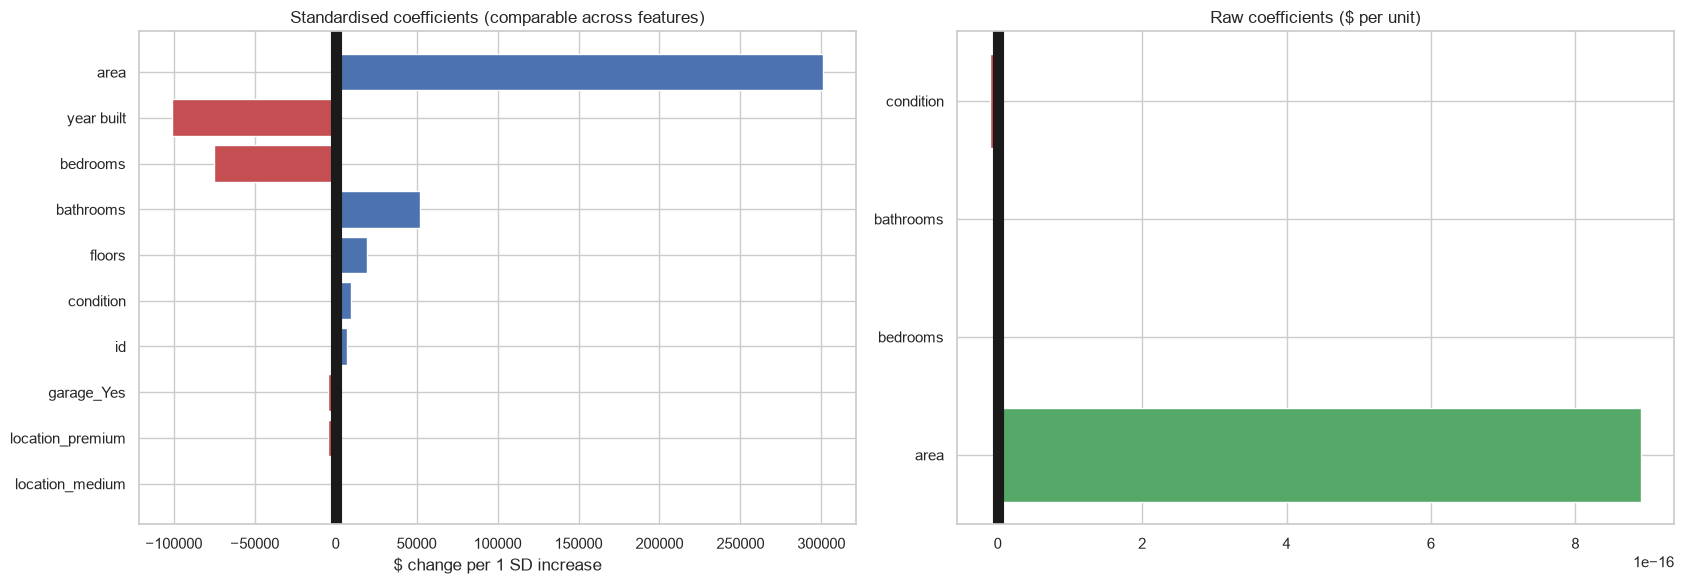

         feature  coefficient
            area          0.0
      year built          0.0
        bedrooms          0.0
       bathrooms          0.0
          floors         -0.0
       condition         -0.0
              id          0.0
      garage_Yes         -0.0
location_premium         -0.0
 location_medium          0.0


In [49]:
coefs = pd.DataFrame({"feature": X.columns, "coefficient": lin.coef_})
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
lin_std = LinearRegression().fit(Xs_train, y_train)
coefs["std_coefficient"] = lin_std.coef_
coefs["abs_std"] = coefs["std_coefficient"].abs()
coefs = coefs.sort_values("abs_std", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(17,6))
top = coefs.head(12).iloc[::-1]
axes[0].barh(top["feature"], top["std_coefficient"],color=["#C44E52" if v < 0 else "#4C72B0" for v in top["std_coefficient"]])
axes[0].axvline(0, color="k", lw=8)
axes[0].set_title("Standardised coefficients (comparable across features)")
axes[0].set_xlabel("$ change per 1 SD increase")

raw = coefs.set_index("feature").loc[[c for c in ["area", "bedrooms","bathrooms","age","garage_spaces","condition","lot_size"]if c in coefs["feature"].values]]

axes[1].barh(raw.index, raw["coefficient"],color=["#C44E52" if v < 0 else "#55A868" for v in raw["coefficient"]])
axes[1].axvline(0, color="k", lw=8)
axes[1].set_title("Raw coefficients ($ per unit)")
plt.tight_layout(); plt.show()
print(coefs[["feature", "coefficient"]].head(12).round(2).to_string(index=False))

observation

The coefficient analysis script plots both standardized and raw regression coefficients to evalute feature impact.
 
 the Standardized coefficient chart shows that area has the largesrt positive magnitude on price per standard deviation incease. 

In [50]:
TRUE_C0EFS = {
    "area": 120,
    "bedrooms": 9500,
    "bathrooms": 17000,
    "garage_spaces": 1.5,
    "condition": 6200,
}

In [51]:

    print("Real dataset in use - no ground-truth coefficients to compare against.")
    print("\nTop fratures by coefficient magnitude:")
    print(coefs[["feature", "coefficient"]].head(12).round(2).to_string(index=False))

Real dataset in use - no ground-truth coefficients to compare against.

Top fratures by coefficient magnitude:
         feature  coefficient
            area          0.0
      year built          0.0
        bedrooms          0.0
       bathrooms          0.0
          floors         -0.0
       condition         -0.0
              id          0.0
      garage_Yes         -0.0
location_premium         -0.0
 location_medium          0.0


Bonus-Ridge and Lasso

In [52]:
alphas = np.logspace(-2,4,60)

pipelines = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (CV alpha)": make_pipeline(StandardScaler(),RidgeCV(alphas, cv=5)),
    "Lasso (CV alpha)":make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5)),

}

rows = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    r = evaluate(name, y_test,pred)
    cvs = cross_val_score(pipe, X,y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
    r["CV R2"] = cvs.mean()
    rows.append(r)

comparison = pd.DataFrame(rows).set_index("Model")
print(comparison.round(4).to_string(float_format=lambda v: f"{v:,.4f}"))    

ridge_alpha = pipelines["Ridge (CV alpha)"].named_steps["ridgecv"].alpha_
lasso_model = pipelines["Lasso (CV alpha)"].named_steps["lassocv"]

lasso_alpha = lasso_model.alpha_
lasso_coef = lasso_model.coef_
print(f"\nchosen alpha - Ridge: {ridge_alpha:.3f} | Lasso: {lasso_alpha:.3f}")
print(f"Features zeroed out by Lasso:" f"{(lasso_coef ==0).sum()} / {len(lasso_coef)}")
if (lasso_coef == 0).sum():
    print("Dropped:", list(X.columns[lasso-coef == 0]))










                           MSE          MAE     R2   MAPE%  CV R2
Model                                                            
Linear Regression 257,431.3043 173,231.3709 0.5313 36.8023 0.5444
Ridge (CV alpha)  256,630.9585 171,842.1694 0.5342 36.5292 0.5445
Lasso (CV alpha)  257,367.5744 173,112.4523 0.5315 36.7745 0.5441

chosen alpha - Ridge: 57.904 | Lasso: 186.718
Features zeroed out by Lasso:0 / 10


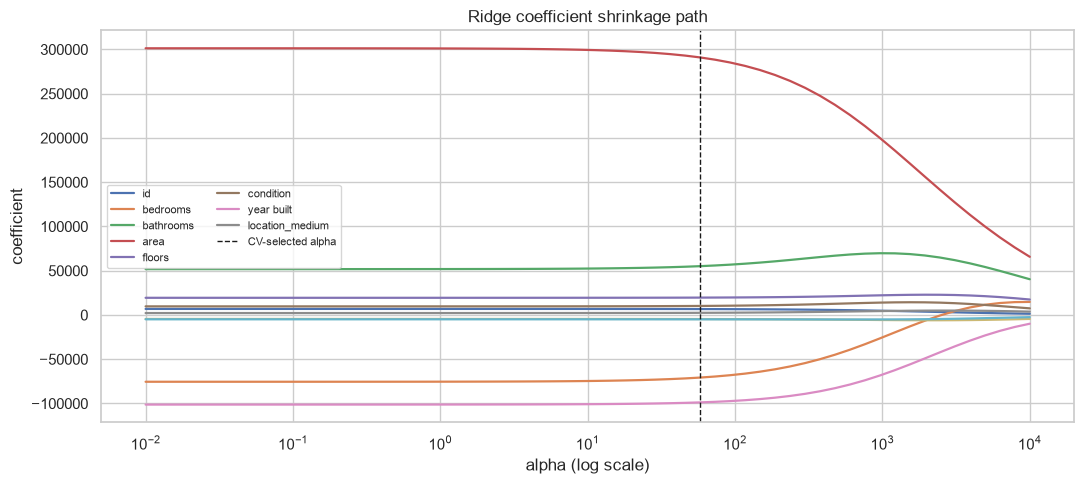

In [53]:
coef_path = []
Xs = StandardScaler().fit_transform(X_train)
for a in alphas:
    coef_path.append(Ridge(alpha=a).fit(Xs, y_train).coef_)
coef_path = np.array(coef_path)

plt.figure(figsize=(11, 5))
for i, col in enumerate(X.columns):
    plt.plot(alphas, coef_path[:, i], lw=1.6, label=col if i < 8 else None)
plt.xscale("log");plt.axvline(ridge_alpha, color="k", ls="--", lw=1, label="CV-selected alpha")
plt.xlabel("alpha (log scale)");
plt.ylabel("coefficient")
plt.title("Ridge coefficient shrinkage path")
plt.legend(fontsize=8, ncol=2);
plt.tight_layout(); plt.show()  


Obervation

the ridge coefficient shrinkage path plot illustrates how feature weights decrease as the regulation strength increases on a log scale.

Feature with higher intial coefficients ,such as area,shrink significantly as  grows, while smaller coefficients remain near zero.

The vwrtical dashed line markes the cross-validaion -selected optiomal alpha (~70) used to balance model complexity and bias.